In [1]:
# asyncpg: 비동기, httpx: 외부 API(http)비동기 호출
%pip install asyncpg httpx python-dotenv
%pip install requests


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
# 테스트용 초기 state 만들기
from state import TravelState, UserInput, Place, make_initial_state
from constants.mocks import mock_user_input

initial_state = make_initial_state(mock_user_input)

In [4]:
# [노드] validate_input
# 사용자 입력 -> 좌표 변환, 식사 시간 계산 (전처리)
from nodes.validate_input import validate_input

validate_result = validate_input(initial_state)
print("validate_input 결과:", validate_result)


validate_input 결과: {'user_input': {'location': '강릉', 'party_size': 2, 'party_type': '연인', 'genders': '혼성', 'age_group': '20대', 'duration': '당일', 'mood_preferences': ['활기찬', '힐링', '이색'], 'activity_preferences': ['카페', '게임/보드게임', '동물체험', '액티비티', '바다', '이색체험'], 'dislike_keywords': ['카페', 'PC방', '술집'], 'trip_date': '2026-04-24', 'start_time': '10:00', 'end_time': '19:00', 'total_hours': 8.0, 'center_lat': 37.8034055083125, 'center_lng': 128.910210247605, 'search_radius_km': 1.5, 'needs_meal': True, 'meal_times': ['12:30', '18:30'], 'final_keywords': ['카페', '게임/보드게임', '동물체험', '액티비티', '바다', '이색체험', '맛집']}, 'errors': [], 'warnings': [], 'step': 'validated'}


In [5]:
# [노드] fetch_candidates
# kakao Local API로 raw 후보 풀 수집 + PostgreSQL
from nodes.fetch_candidates import fetch_candidates

candidates_result = await fetch_candidates(validate_result)
print("candidates_result 결과:", candidates_result)


candidates_result 결과: {'user_input': {'location': '강릉', 'party_size': 2, 'party_type': '연인', 'genders': '혼성', 'age_group': '20대', 'duration': '당일', 'mood_preferences': ['활기찬', '힐링', '이색'], 'activity_preferences': ['카페', '게임/보드게임', '동물체험', '액티비티', '바다', '이색체험'], 'dislike_keywords': ['카페', 'PC방', '술집'], 'trip_date': '2026-04-24', 'start_time': '10:00', 'end_time': '19:00', 'total_hours': 8.0, 'center_lat': 37.8034055083125, 'center_lng': 128.910210247605, 'search_radius_km': 1.5, 'needs_meal': True, 'meal_times': ['12:30', '18:30'], 'final_keywords': ['카페', '찻집', '보드게임카페', 'PC방', '오락실', '방탈출카페', 'VR체험', '동물카페', '고양이카페', '강아지카페', '라쿤카페', '양카페', '동물원', '수족관', '아쿠아리움', '짚라인', '루지', '케이블카', '번지점프', '놀이공원', '워터파크', '테마파크', '스포츠 시설', '해변', '해수욕장', '해안산책로', '바다', '이색체험', '팝업스토어', '글램핑', '캠핑장', '온천', '스파', '찜질방', '야시장', '드로잉카페', '한복', '한옥카페', '전통찻집', '갯벌체험', '체험', '맛집', '음식점']}, 'candidates': [{'id': '1483638466', 'name': '달빛491커피', 'category': '음식점 > 카페', 'category_group_code': 'CE7', 'phone': 

In [6]:
from nodes.filter_candidates import filter_candidates

filter_result = filter_candidates(candidates_result)
print("filter_result 결과:", filter_result)

filter_result 결과: {'filtered_candidates': [{'id': '82574588', 'name': '라카이게임캠프', 'category': '가정,생활 > 여가시설 > 오락실', 'category_group_code': '', 'phone': '', 'address_name': '강원특별자치도 강릉시 안현동 89-87', 'road_address_name': '강원특별자치도 강릉시 해안로 536', 'lat': 37.8070551652561, 'lng': 128.904458091598, 'place_url': 'http://place.map.kakao.com/82574588', 'tags': [], 'rating': 0.0, 'avg_stay_minutes': 60, 'open_hours': {}}, {'id': '1205517587', 'name': '경포아쿠아리움', 'category': '문화,예술 > 문화시설 > 아쿠아리움', 'category_group_code': 'CT1', 'phone': '033-645-7887', 'address_name': '강원특별자치도 강릉시 초당동 505', 'road_address_name': '강원특별자치도 강릉시 난설헌로 131', 'lat': 37.7908073932944, 'lng': 128.9063701799303, 'place_url': 'http://place.map.kakao.com/1205517587', 'tags': [], 'rating': 0.0, 'avg_stay_minutes': 60, 'open_hours': {}}, {'id': '27367576', 'name': '경포석호생태관', 'category': '문화,예술 > 문화시설 > 전시관', 'category_group_code': 'CT1', 'phone': '', 'address_name': '강원특별자치도 강릉시 초당동 505', 'road_address_name': '강원특별자치도 강릉시 난설헌로 131',

In [7]:
# LangGraph 그래프 빌드
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(TravelState)

# 노드 등록
graph_builder.add_node("validate_input", validate_input)
graph_builder.add_node("fetch_candidates", fetch_candidates)

# 엣지 (직선 연결)
graph_builder.add_edge(START, "validate_input")
graph_builder.add_edge("validate_input", "fetch_candidates")
graph_builder.add_edge("fetch_candidates", END)

graph = graph_builder.compile()

In [8]:
# 그래프 실행
state_v1 = await graph.ainvoke(initial_state)

print(f"📍 위치: {state_v1['user_input']['location']}")
print(f"📌 좌표: ({state_v1['user_input']['center_lat']}, {state_v1['user_input']['center_lng']})")
print(f"🔍 Kakao raw 후보: {len(state_v1['candidates'])}개")
print(f"⚠️  warnings: {state_v1['warnings']}")
print(f"❌ errors: {state_v1['errors']}")
print(f"✅ step: {state_v1['step']}\n")

print("=== 후보 샘플 (상위 5개) ===")
for p in state_v1["candidates"][:5]:
    print(
        f"  [{p.get('category_group_code', '기타')}] {p['name']} - "
        f"{p.get('road_address_name') or p.get('address_name', '')}"
    )

📍 위치: 강릉
📌 좌표: (37.8034055083125, 128.910210247605)
🔍 Kakao raw 후보: 146개
⚠️  warnings: []
❌ errors: []
✅ step: fetched

=== 후보 샘플 (상위 5개) ===
  [CE7] 달빛491커피 - 강원특별자치도 강릉시 창해로 491
  [CE7] 빽다방 강릉경포해변점 - 강원특별자치도 강릉시 창해로 473
  [CE7] 투썸플레이스 경포스카이베이점 - 강원특별자치도 강릉시 해안로 476
  [CE7] 메가MGC커피 경포해수욕장점 - 강원특별자치도 강릉시 창해로 431
  [CE7] 아우라 - 강원특별자치도 강릉시 창해로 423


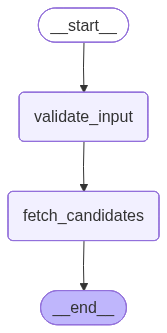

In [9]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))